### lesson \#24 by Storchak Vasyl

In [44]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import pytorch_lightning as pl
import torchvision
import torchvision.transforms as transforms
import random


from torch import nn
from torchvision.datasets import MNIST
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split, Dataset
from pytorch_lightning.loggers import TensorBoardLogger
from pytorch_lightning.callbacks import ModelCheckpoint

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import KFold

In [53]:
device = 'cuda'
# wtf ?
batch_size = 16
precision_model = '32' #'bf16-mixed'

data_precision_torch = torch.float32
match precision_model:
    case 'bf16-mixed': 
        data_precision_torch = torch.float16
    case '16': 
        data_precision_torch = torch.float16
    case '32-mixed': 
        data_precision_torch = torch.float32
    case '32': 
        data_precision_torch = torch.float32
    case '64': 
        data_precision_torch = torch.float64
    
num_workers = 16
epochs = 10

transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

batch_size = 4

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                          shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size,
                                         shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')
model_name = f'mnist_{str(batch_size)}_{str(precision_model)}_{str(epochs)}.pt'

In [8]:
model_name

'mnist_4_64_100.pt'

In [32]:
class MNISTModel(pl.LightningModule):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 4 * 4, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1) # flatten all dimensions except batch
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = F.cross_entropy(logits, y)
        self.log("train_loss", loss)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        preds = torch.argmax(logits, dim=1)
        acc = (preds == y).float().mean()
        self.log("val_acc", acc, prog_bar=True)

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=1e-3)

In [49]:
class MNISTDataModule(pl.LightningDataModule):
    def __init__(self, data_dir: str = "./data", batch_size: int=64, num_workers: int=4):
        super().__init__()
        self.data_dir = data_dir
        self.batch_size = batch_size
        self.num_workers = num_workers

        self.transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.1307,), (0.3081,))  # mean & std of MNIST
        ])
        self.setup()

    def prepare_data(self):
        datasets.MNIST(self.data_dir, train=True, download=True)
        datasets.MNIST(self.data_dir, train=False, download=True)

    def setup(self, stage=None):
        if stage == 'fit' or stage is None:
            full_train = datasets.MNIST(self.data_dir, train=True, transform=self.transform)
            train_size = int(0.8 * len(full_train))
            val_size = len(full_train) - train_size
            self.mnist_train, self.mnist_val = random_split(full_train, [train_size, val_size])

        if stage == 'test' or stage is None:
            self.mnist_test = datasets.MNIST(self.data_dir, train=False, transform=self.transform)

    def train_dataloader(self):
        return DataLoader(self.mnist_train, batch_size=self.batch_size, shuffle=True, num_workers=self.num_workers)

    def val_dataloader(self):
        return DataLoader(self.mnist_val, batch_size=self.batch_size, shuffle=False, num_workers=self.num_workers)

    def test_dataloader(self):
        return DataLoader(self.mnist_test, batch_size=self.batch_size, shuffle=False, num_workers=self.num_workers)


In [35]:
model = MNISTModel()

In [36]:
logger = TensorBoardLogger("tb_logs", name="MNISTModel")

checkpoint_callback = ModelCheckpoint(
    monitor="val_acc",         
    dirpath="checkpoints/",     
    filename="best-checkpoint",  
    save_top_k=3,              
    mode="min"                    
)

dm = MNISTDataModule(
    batch_size=batch_size, 
    num_workers=num_workers,
)

trainer = pl.Trainer(
    logger=logger,
    callbacks=[checkpoint_callback],
    max_epochs=epochs, 
    accelerator='gpu' if torch.cuda.is_available() and device == 'cuda' else 'cpu',
    precision=precision_model,
    detect_anomaly=True,
    accumulate_grad_batches=batch_size
)

trainer.fit(model, datamodule=dm)

torch.save(model.state_dict(), model_name)

print(f"Model saved to {model_name}")

You have turned on `Trainer(detect_anomaly=True)`. This will significantly slow down compute speed and is recommended only for model debugging.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name  | Type      | Params | Mode 
--------------------------------------------
0 | conv1 | Conv2d    | 156    | train
1 | pool  | MaxPool2d | 0      | train
2 | conv2 | Conv2d    | 2.4 K  | train
3 | fc1   | Linear    | 30.8 K | train
4 | fc2   | Linear    | 10.2 K | train
5 | fc3   | Linear    | 850    | train
--------------------------------------------
44.4 K    Trainable params
0         Non-trainable params
44.4 K    Total params
0.178     Total estimated model params size (MB)
6         Modules in train mode
0         Modules in eval mode


Sanity Checking: |                                                                           | 0/? [00:00<?, ?…

Training: |                                                                                  | 0/? [00:00<?, ?…

Validation: |                                                                                | 0/? [00:00<?, ?…

Validation: |                                                                                | 0/? [00:00<?, ?…

...

Validation: |                                                                                | 0/? [00:00<?, ?…

Validation: |                                                                                | 0/? [00:00<?, ?…

Validation: |                                                                                | 0/? [00:00<?, ?…


Detected KeyboardInterrupt, attempting graceful shutdown ...


NameError: name 'exit' is not defined

In [ ]:
# i stop manual training on 12 epoch

In [42]:
!tensorboard --logdir tb_logs

2025-08-16 00:28:54.544944: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1755293334.561586   71736 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1755293334.566660   71736 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1755293334.580038   71736 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1755293334.580059   71736 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1755293334.580062   71736 computation_placer.cc:177] computation placer alr

![title](sc.png)


In [45]:
model.eval()
device = next(model.parameters()).device  # get device of model
model.to(device)

MNISTModel(
  (conv1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=256, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)

In [65]:
test_dm = MNISTDataModule()

test_loader = test_dm.test_dataloader()
test_dataset = test_loader.dataset
indices = random.sample(range(len(test_dataset)), 10)

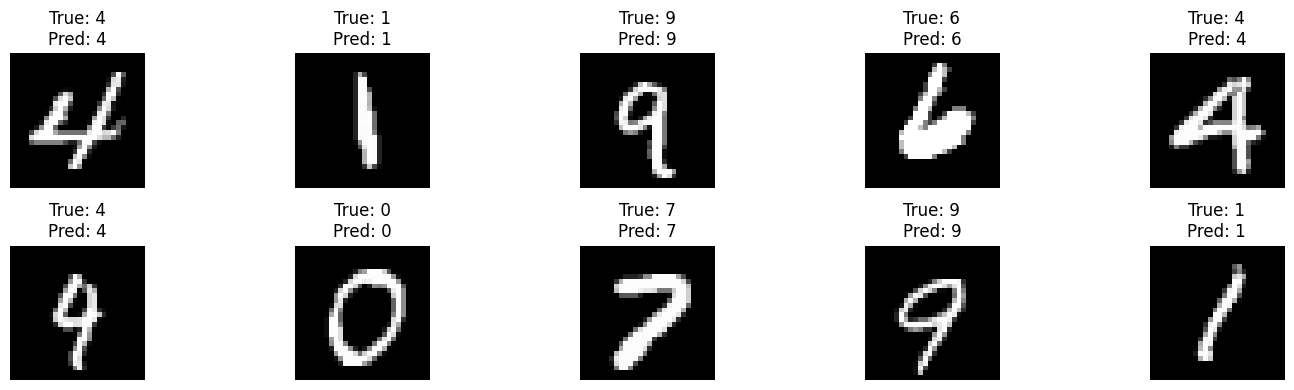

In [66]:
plt.figure(figsize=(15, 4))
model.float()
model.to(device)

for i, idx in enumerate(indices):
    img, label = test_dataset[idx]
    img_tensor = img.unsqueeze(0).to(device)
    
    with torch.no_grad():
        logits = model(img_tensor)
        pred = torch.argmax(logits, dim=1).item()
    
    plt.subplot(2, 5, i+1)
    plt.imshow(img.squeeze(), cmap='gray')
    plt.title(f"True: {label}\nPred: {pred}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# perfect work